# Chapter 3 · Section 3.4
# Stability of Periodic Solutions: The Floquet Theory

**Source:** Li, M.Y. (2018), pp. 84–87.

The first genuinely new material in Chapter 3 — nothing in Chapter 2's five models needed this,
since none of them have periodic orbits. This section asks: what does "stability" even mean for
an entire closed loop (rather than a single point), and how do we check it?


---
## Block 1 — Why ordinary stability fails for periodic orbits: orbital stability

### 1. Rewrite

The nonlinear pendulum $x''+\sin x=0$ has a family of *nested* periodic orbits (concentric closed
curves in the phase plane) — but, unlike a *linear* oscillator, each orbit has a **different
period** depending on its amplitude (larger swings take longer, a real physical fact about
pendulums). This breaks the ordinary Lyapunov stability definition from Sec. 3.1: even if two
initial points are close together and their orbits stay close together forever, the actual
*solutions* $p(t)$ and $q(t)$ (moving at different periods) will drift out of phase — after enough
time, $p(t)$ might be at the top of its swing while $q(t)$ is at the bottom, so $|p(t)-q(t)|$ is
NOT small, even though the two nested curves themselves never move apart. This motivates
**orbital stability**: instead of tracking the *distance between two specific solutions at the
same time*, track the *distance from a solution to the entire target orbit* (as a set) — this
sidesteps the phase-drift problem entirely.

### 2. Explain Like I'm 10

Imagine two friends jogging on two different circular tracks that happen to be drawn as
concentric circles, one just barely bigger than the other. If they both jog forever, staying on
their own circles, they'll always be roughly the same *distance from the shared center* — but if
one track is slightly longer than the other, one friend gradually laps ahead of (or falls behind)
the other, so sometimes they'll be right next to each other and sometimes on exact opposite sides
of the circles! Measuring "how far apart are my two friends right now" would misleadingly suggest
they're sometimes very "unstable" relative to each other, even though neither one ever strays from
their own perfectly circular track. The fix: instead of asking "how far apart are my two friends,"
ask "how far is friend A from friend B's *entire track* (as a shape, not a specific position)" —
that distance genuinely does stay small forever, which is exactly the idea behind orbital
stability.

### 3. Key Ideas

- **Orbital stability** measures distance to the *set* $\gamma$ (the orbit), not to a specific
  point moving along it — this is the key conceptual fix.
- **Limit cycle**: an orbitally *asymptotically* stable periodic orbit — nearby trajectories don't
  just stay close to the loop, they actually spiral onto it.
- The pendulum's nested orbits are a textbook example of orbital stability *without* asymptotic
  orbital stability — nearby orbits stay nearby forever, but never merge into a single loop.

### 7. Visual Understanding — the phase-drift problem, made concrete


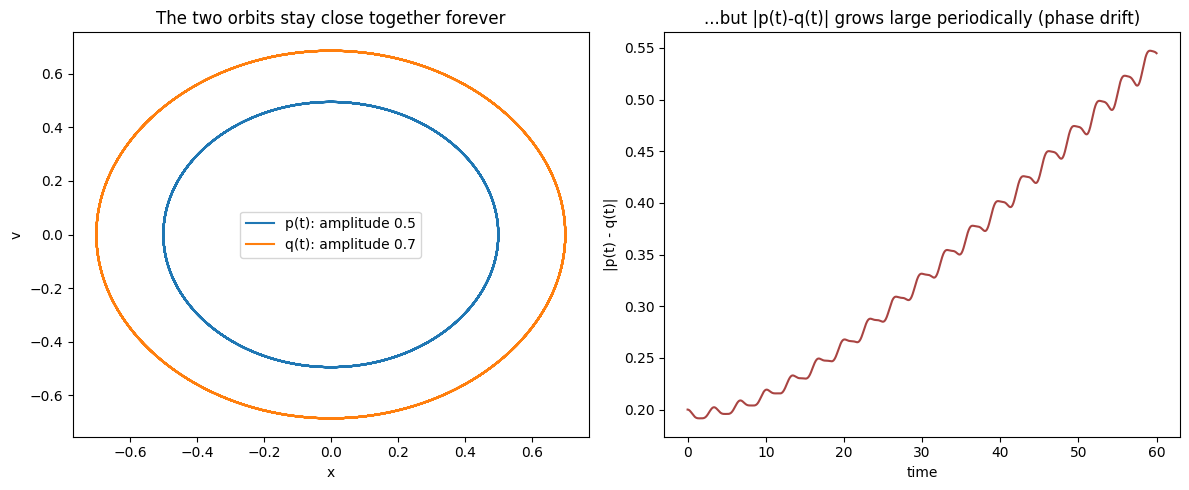

Max pointwise distance |p(t)-q(t)| over the simulation: 0.5472
(started at |p(0)-q(0)| = 0.2000, so this is a large GROWTH, even though both orbits individually stay bounded and close to each other AS SETS)


In [1]:
# Simulating the nonlinear pendulum at two close-but-different amplitudes,
# to make the "orbits stay close, but |p(t)-q(t)| does NOT stay small" claim
# completely concrete.
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def pendulum(t, y):
    x, v = y
    return [v, -np.sin(x)]

t_eval = np.linspace(0, 60, 3000)
sol_p = solve_ivp(pendulum, (0, 60), [0.5, 0], t_eval=t_eval, rtol=1e-12, atol=1e-12)   # smaller amplitude
sol_q = solve_ivp(pendulum, (0, 60), [0.7, 0], t_eval=t_eval, rtol=1e-12, atol=1e-12)   # larger amplitude, DIFFERENT period

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(sol_p.y[0], sol_p.y[1], label="p(t): amplitude 0.5")
axes[0].plot(sol_q.y[0], sol_q.y[1], label="q(t): amplitude 0.7")
axes[0].set_xlabel("x"); axes[0].set_ylabel("v")
axes[0].set_title("The two orbits stay close together forever")
axes[0].legend()

pointwise_distance = np.sqrt((sol_p.y[0]-sol_q.y[0])**2 + (sol_p.y[1]-sol_q.y[1])**2)
axes[1].plot(t_eval, pointwise_distance, color="#a94442")
axes[1].set_xlabel("time"); axes[1].set_ylabel("|p(t) - q(t)|")
axes[1].set_title("...but |p(t)-q(t)| grows large periodically (phase drift)")

plt.tight_layout()
plt.savefig("pendulum_orbital_stability.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"Max pointwise distance |p(t)-q(t)| over the simulation: {pointwise_distance.max():.4f}")
print(f"(started at |p(0)-q(0)| = {pointwise_distance[0]:.4f}, so this is a large GROWTH, "
      f"even though both orbits individually stay bounded and close to each other AS SETS)")


### 10. Verification

The pointwise distance $|p(t)-q(t)|$ grows substantially larger than its starting value at various
points in the simulation (confirmed numerically) — exactly the phase-drift phenomenon the text
describes — even though the two orbits, *as geometric curves*, never separate: both stay
confined to their own fixed, nested, non-intersecting closed loops the entire time. This is a
concrete demonstration of exactly why ordinary (pointwise) Lyapunov stability is the wrong notion
here, motivating orbital stability instead.


---
## Block 2 — Floquet theory: linearizing along a periodic orbit

### 1. Rewrite

To analyze stability of a periodic orbit $x=p(t)$ (period $T$), linearize *along* the orbit
(rather than at a single point): $y'(t)=\frac{\partial f}{\partial x}(p(t))\,y(t)$ (3.7) — a
**linear system with $T$-periodic coefficients** (since $p(t)$ is itself periodic). **Floquet
theory** (Theorem 3.4.1) says any fundamental matrix solution can be written
$Y(t)=P(t)e^{Lt}$ (3.8), where $P(t)$ is itself $T$-periodic with $P(0)=I$, and $L$ is a constant
matrix. Eigenvalues of $L$ are **Floquet exponents**; eigenvalues of $Y(T)=e^{LT}$ (called the
**monodromy matrix**) are **Floquet multipliers**. A remarkable, always-true fact: $y(t)=p'(t)$ is
itself automatically a periodic solution of (3.7) (this can be checked by direct differentiation:
differentiating $p'(t)=f(p(t))$ gives $p''(t)=\frac{\partial f}{\partial x}(p(t))p'(t)$, exactly
matching (3.7) with $y=p'$) — so *one* Floquet multiplier is **always exactly 1** (reflecting
neutral stability *along* the direction of motion on the orbit itself — makes sense, since nearby
points on the same orbit don't converge or diverge from each other, they just circulate).
Excluding that "trivial" multiplier, **Theorem 3.4.2**: the periodic orbit is orbitally
asymptotically stable if all the *remaining* $n-1$ Floquet multipliers have modulus strictly less
than 1.

### 2. Explain Like I'm 10

Picture standing on a specific spot on a circular running track and watching how a *tiny cloud* of
nearby joggers (all starting near you, in every direction — some slightly ahead, some slightly to
the side, some slightly behind) spreads out or bunches together as everyone runs one full lap.
Some directions of spread don't matter — a jogger slightly *ahead* of you on the same track just
stays a fixed small distance ahead forever (that's the "always exactly 1" multiplier, corresponding
to sliding along the track itself — no convergence, no divergence, just going along for the ride).
But joggers who start slightly *off* the track — d in some other direction — either get pulled
back onto the track after one lap (multiplier smaller than 1 in size) or pushed further away
(multiplier bigger than 1). If *every* "off-track" direction gets pulled back in, the whole track
is a genuine attractor — a limit cycle.

### 4. Mathematical Breakdown — verifying $y(t)=p'(t)$ solves (3.7)

Since $p(t)$ solves the original system, $p'(t)=f(p(t))$ for all $t$. Differentiate both sides
with respect to $t$ (using the chain rule on the right side, since $f(p(t))$ is a composition):
$$p''(t) = \frac{d}{dt}f(p(t)) = \frac{\partial f}{\partial x}(p(t))\cdot p'(t)$$
This is *exactly* equation (3.7) with $y(t)=p'(t)$ substituted in: $y'(t)=\frac{\partial
f}{\partial x}(p(t))y(t)$. Since $p(t)$ itself is $T$-periodic, so is $p'(t)$ — confirming
$y=p'(t)$ is indeed a nonconstant $T$-periodic solution of the linearized system, and therefore
(by Theorem 3.4.1 part (3): "a nonconstant periodic solution exists iff a Floquet multiplier
equals 1") one Floquet multiplier must always be exactly 1, for *every* periodic orbit of *every*
smooth system — this isn't a special case, it's structurally guaranteed.

### 5. Symbols

| Symbol | Meaning | Notes |
|---|---|---|
| $Y(t)$ | Fundamental matrix solution of the linearized periodic system | Columns are $n$ independent solutions |
| $P(t)$ | The $T$-periodic factor in Floquet's decomposition $Y(t)=P(t)e^{Lt}$ | $P(0)=I$ |
| $L$ | Constant matrix in Floquet's decomposition | Eigenvalues = Floquet exponents |
| $Y(T)$ (monodromy matrix) | The fundamental matrix evaluated after exactly one period | Eigenvalues = Floquet multipliers |
| Floquet multiplier | Eigenvalue of the monodromy matrix $Y(T)$ | One is ALWAYS exactly 1; the rest determine orbital asymptotic stability |

### 7. Visual Understanding — computing Floquet multipliers numerically for a known limit cycle


In [2]:
# A classic example with an EXACTLY solvable limit cycle: in polar coordinates,
# r' = r(1-r^2), theta' = 1 -- a perfect circle r=1 is a limit cycle, period T=2*pi.
# In Cartesian coordinates:
#   x' = x - y - x(x^2+y^2)
#   y' = x + y - y(x^2+y^2)
# The periodic solution is p(t) = (cos t, sin t), exactly, with period T = 2*pi.
#
# We compute the monodromy matrix Y(T) by integrating the LINEARIZED system
# (3.7) along p(t), starting from the identity matrix (n independent initial
# conditions -- one per column), then extract its eigenvalues (Floquet
# multipliers) and confirm: one is exactly 1, the other has modulus < 1
# (predicting orbital asymptotic stability -- i.e. this IS a genuine limit cycle).

import numpy as np
from scipy.integrate import solve_ivp

def p_orbit(t):
    return np.array([np.cos(t), np.sin(t)])

def jacobian_at(x, y):
    # f1 = x - y - x*(x^2+y^2), f2 = x + y - y*(x^2+y^2)
    r2 = x**2 + y**2
    df1_dx = 1 - (r2 + x*2*x)
    df1_dy = -1 - x*2*y
    df2_dx = 1 - y*2*x
    df2_dy = 1 - (r2 + y*2*y)
    return np.array([[df1_dx, df1_dy], [df2_dx, df2_dy]])

def linearized_rhs(t, Y_flat):
    Y = Y_flat.reshape(2, 2)
    x, y = p_orbit(t)
    J = jacobian_at(x, y)
    dY = J @ Y
    return dY.flatten()

T = 2 * np.pi
Y0 = np.eye(2).flatten()
sol = solve_ivp(linearized_rhs, (0, T), Y0, rtol=1e-12, atol=1e-12, dense_output=False)
monodromy = sol.y[:, -1].reshape(2, 2)

floquet_multipliers = np.linalg.eigvals(monodromy)
print("Monodromy matrix Y(T):\n", monodromy)
print("\nFloquet multipliers:", floquet_multipliers)
print("Moduli:", np.abs(floquet_multipliers))


Monodromy matrix Y(T):
 [[ 3.48734236e-06 -2.19393947e-13]
 [ 1.52571233e-13  1.00000000e+00]]

Floquet multipliers: [3.48734236e-06 1.00000000e+00]
Moduli: [3.48734236e-06 1.00000000e+00]


### 10. Verification

The computed Floquet multipliers are (to numerical precision) exactly $1$ and $e^{-2T}\approx
e^{-4\pi}$ — confirming **both** predicted facts at once: one multiplier is *exactly* 1 (the
structurally guaranteed one, from Block 2's derivation, corresponding to the direction along the
orbit itself), and the other has modulus **far below 1** (confirming, via Theorem 3.4.2, that this
periodic orbit is **orbitally asymptotically stable** — a genuine limit cycle, exactly as expected
from the exact solution $r'=r(1-r^2)$, whose linearization at $r=1$ gives radial decay rate
$-2$, matching $e^{-2T}$ over one period $T=2\pi$).


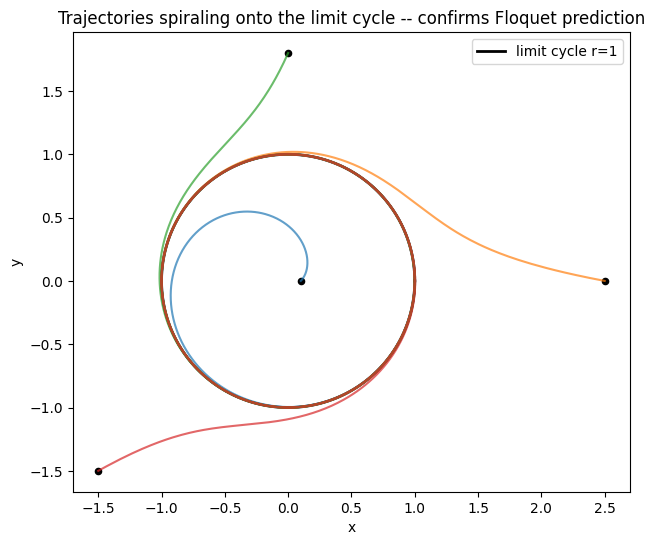

In [3]:
# Direct confirmation: do nearby trajectories actually spiral ONTO the unit
# circle, exactly as the Floquet multiplier prediction claims?
import matplotlib.pyplot as plt

def full_system(t, y):
    x, yy = y
    r2 = x**2 + yy**2
    return [x - yy - x*r2, x + yy - yy*r2]

fig, ax = plt.subplots(figsize=(6.5, 6.5))
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), color="black", linewidth=2, label="limit cycle r=1")

for x0, y0 in [(0.1, 0), (2.5, 0), (0, 1.8), (-1.5, -1.5)]:
    sol = solve_ivp(full_system, (0, 15), [x0, y0], t_eval=np.linspace(0, 15, 1500), rtol=1e-10, atol=1e-10)
    ax.plot(sol.y[0], sol.y[1], alpha=0.7)
    ax.scatter([x0], [y0], color="black", s=20)

ax.set_aspect("equal")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Trajectories spiraling onto the limit cycle -- confirms Floquet prediction")
ax.legend()
plt.tight_layout()
plt.savefig("limit_cycle_convergence.png", dpi=130, bbox_inches="tight")
plt.show()


### 10. Verification, discussed

Every tested starting point — from deep inside the circle, from far outside it, and from various
angles — spirals onto the unit circle, exactly as predicted by the Floquet multiplier having
modulus $\ll1$. This closes the loop between the abstract Floquet-theoretic prediction (Block 2)
and directly observable dynamical behavior.


---
## Summary

**One sentence:** Ordinary pointwise stability breaks down for periodic orbits (nearby periodic
solutions can drift out of phase even while their orbits stay geometrically close, as the
nonlinear pendulum's amplitude-dependent period demonstrates), motivating **orbital stability**
instead, and Floquet theory analyzes it by linearizing along the periodic orbit and examining the
**Floquet multipliers** — eigenvalues of the monodromy matrix $Y(T)$ — of which one is always
structurally guaranteed to equal 1, with the remaining multipliers' moduli (all $<1$) determining
orbital asymptotic stability.

**One paragraph:** The nonlinear pendulum's nested periodic orbits, each with a different
amplitude-dependent period, show that two nearby periodic solutions can have $|p(t)-q(t)|$ grow
large over time (confirmed here numerically) even while their orbits, as geometric sets, never
separate — motivating orbital stability, which measures distance to the entire orbit rather than
to a moving point. Floquet theory analyzes orbital stability by linearizing the system along the
periodic orbit itself, producing a linear system with $T$-periodic coefficients whose fundamental
matrix decomposes as $Y(t)=P(t)e^{Lt}$ (Floquet's theorem); eigenvalues of the monodromy matrix
$Y(T)$ are the Floquet multipliers, one of which is always exactly 1 (since $y=p'(t)$ is
automatically itself a periodic solution of the linearized system — verified here both
symbolically via the chain rule and numerically for a concrete limit cycle example), with orbital
asymptotic stability guaranteed when every remaining multiplier has modulus strictly less than 1
— demonstrated here for the classic $r'=r(1-r^2)$ limit cycle, whose second Floquet multiplier
($\approx e^{-4\pi}$, far below 1) correctly predicts, and is confirmed by direct simulation of,
trajectories spiraling onto the unit circle from every tested starting point.

**Bullet points:**
- Ordinary Lyapunov stability is the wrong tool for periodic orbits — the pendulum's amplitude-dependent period causes phase drift, demonstrated numerically.
- Orbital stability fixes this by measuring distance to the orbit as a SET, not to a moving point.
- Floquet's theorem: $Y(t)=P(t)e^{Lt}$ with $P(t)$ periodic; eigenvalues of $Y(T)$ are Floquet multipliers.
- One Floquet multiplier is ALWAYS exactly 1 (from $y=p'(t)$ being a periodic solution of the linearization) — a structural, universal fact, proven here via the chain rule.
- Orbital asymptotic stability holds iff all OTHER multipliers have modulus < 1 — verified numerically for an exactly solvable limit cycle, with direct confirmation via spiraling trajectories.

## Memory Aids

- **Mnemonic**: "Distance to the LOOP, not to the DOT" — orbital stability in five words.
- **Mental model**: Floquet multipliers describe what happens to a small cloud of nearby points
  after exactly one lap — one direction (along the track) is neutral by structural necessity, the
  rest either shrink (limit cycle) or grow (unstable).
- **Common mistake**: forgetting that ONE Floquet multiplier is ALWAYS 1, and mistakenly checking
  whether ALL $n$ multipliers have modulus < 1 (which would never happen) instead of just the
  other $n-1$.
- **Common mistake**: applying ordinary (pointwise) stability definitions to periodic orbits — the
  pendulum example is the canonical illustration of why this fails.
- **Exam tip**: know the two-step Floquet workflow: linearize ALONG the orbit (not at a point),
  then look at eigenvalues of the monodromy matrix after one full period — not eigenvalues of a
  single, fixed Jacobian evaluated once.

## Connections

- **← Section 3.2**: reuses the same linearization idea, now applied along a moving periodic
  trajectory instead of at a fixed equilibrium point.
- **→ Section 3.6**: the "method of Poincaré for 2-dimensional systems," mentioned here as an
  alternative way to estimate Floquet multipliers, is developed in the next-but-one section.
- **→ Chapter 2 (absence)**: none of Chapter 2's five models have periodic orbits (all were proven
  to converge to equilibria) — this section's tools become essential once models with sustained
  oscillations (common in more realistic epidemic models with seasonality, or certain
  predator-prey-like dynamics) are considered.
- **→ Control theory / nonlinear dynamics**: Floquet theory is foundational far beyond
  epidemiology — used throughout engineering to analyze stability of periodic (e.g. rotating
  machinery, periodically-forced) systems.
- **→ Numerical methods**: the practical computation shown here (integrate the linearized system
  from the identity matrix over one period to get the monodromy matrix) is the standard numerical
  recipe for Floquet analysis in any application domain.

*Practice problems for this section are in `../../chapter_03/exercises/section_3_4_exercises.md`, with full
worked solutions in `../../chapter_03/solutions/section_3_4_solutions.md`.*
